In [1]:
import pandas as pd
from io import StringIO

def leer_mmpbsa(archivo):

    with open(archivo, 'r', encoding='utf-8') as f:
        lines = f.readlines()

    # Buscar los headers
    posiciones = [
        i for i, line in enumerate(lines)
        if line.strip().startswith('Frame #')
    ]

    print(f"{archivo}")
    print(f"Headers encontrados: {posiciones}")

    if len(posiciones) < 3:
        raise ValueError(
            f"Se encontraron {len(posiciones)} headers. "
            "Se necesita al menos el tercero."
        )

    # Tercer bloque
    inicio = posiciones[3]

    # Termina cuando aparece el siguiente header
    if len(posiciones) > 4:
        fin = posiciones[4]
    else:
        fin = len(lines)

    data = ''.join(lines[inicio:fin])

    df = pd.read_csv(
        StringIO(data),
        index_col='Frame #'
    )

    # Convertir todas las columnas a numéricas
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    return df

In [8]:
df1 = leer_mmpbsa('/media/leandro/My Passport/Andrea/NorwalkSydney_K4L8Z7/DM_SydneyFull_apo/FINAL_RESULTS_MMPBSA.csv')
df2 = leer_mmpbsa('/media/leandro/My Passport/Andrea/NorwalkSydney_K4L8Z7/DM_SydneyP_nano85/FINAL_RESULTS_MMPBSA.csv')
df3 = leer_mmpbsa('/media/leandro/My Passport/Andrea/NorwalkSydney_K4L8Z7/DM_SydneyP_M4/FINAL_RESULTS_MMPBSA.csv')

/media/leandro/My Passport/Andrea/NorwalkSydney_K4L8Z7/DM_SydneyFull_apo/FINAL_RESULTS_MMPBSA.csv
Headers encontrados: [2, 5005, 10008, 15011]
/media/leandro/My Passport/Andrea/NorwalkSydney_K4L8Z7/DM_SydneyP_nano85/FINAL_RESULTS_MMPBSA.csv
Headers encontrados: [2, 5005, 10008, 15011]
/media/leandro/My Passport/Andrea/NorwalkSydney_K4L8Z7/DM_SydneyP_M4/FINAL_RESULTS_MMPBSA.csv
Headers encontrados: [2, 5005, 10008, 15011]


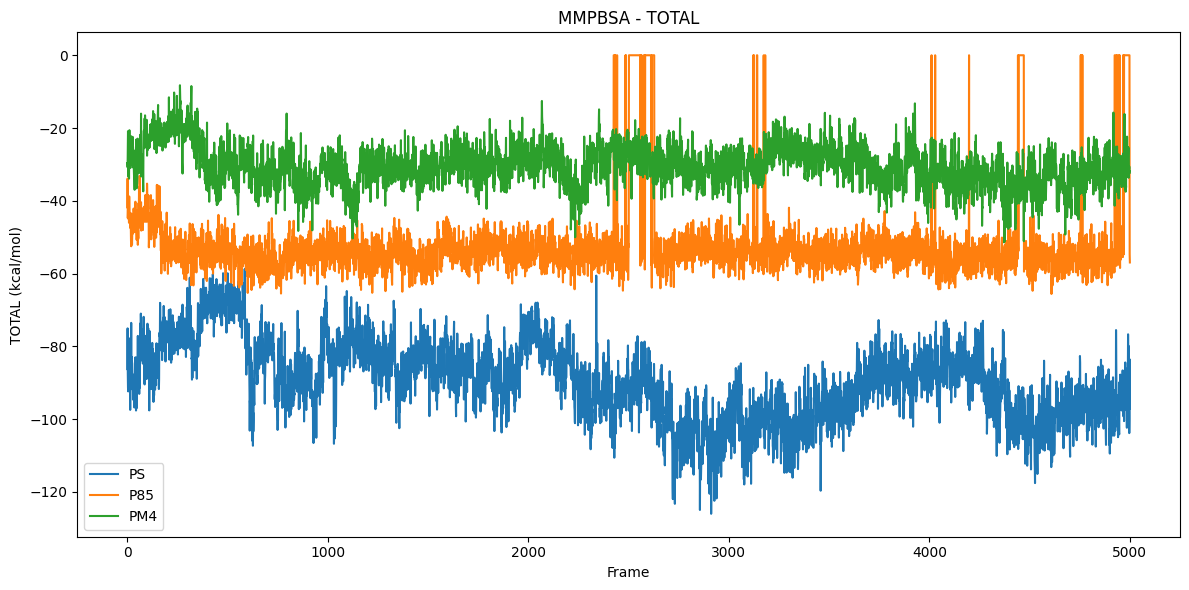

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(df1.index, df1['TOTAL'], label='PS')
plt.plot(df2.index, df2['TOTAL'], label='P85')
plt.plot(df3.index, df3['TOTAL'], label='PM4')
plt.xlabel('Frame')
plt.ylabel('TOTAL (kcal/mol)')
plt.title('MMPBSA - TOTAL')
plt.legend()
plt.tight_layout()

plt.show()

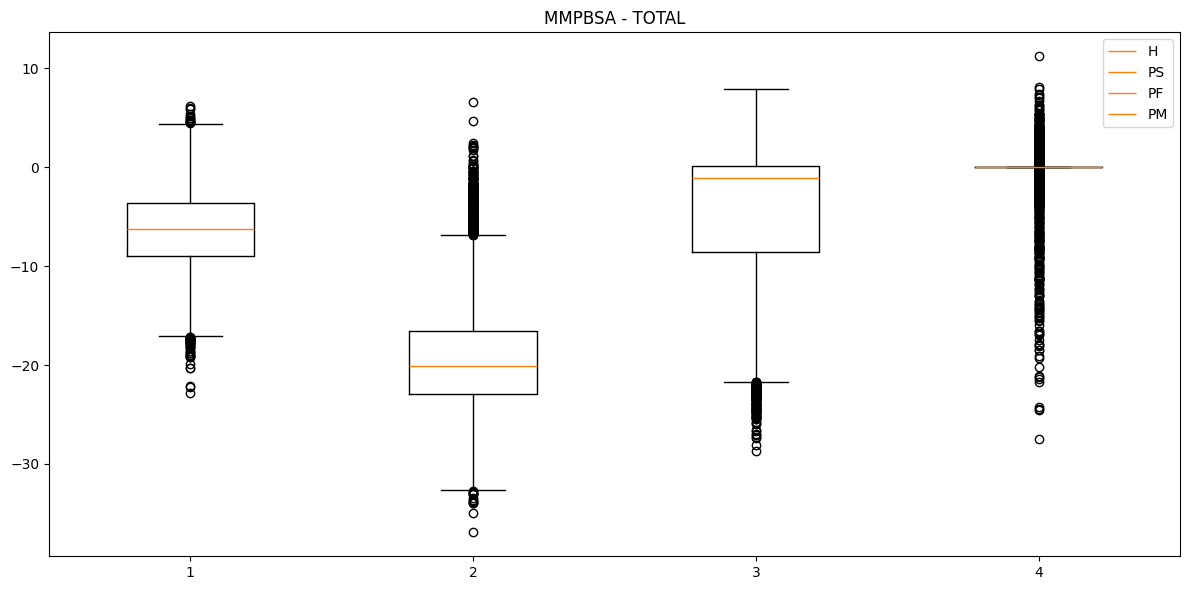

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.boxplot([df1['TOTAL'].dropna(),df2['TOTAL'].dropna(),df3['TOTAL'].dropna(),df4['TOTAL'].dropna()], label=['H','PS','PF','PM'])

plt.title('MMPBSA - TOTAL')
plt.legend()
plt.tight_layout()

plt.show()

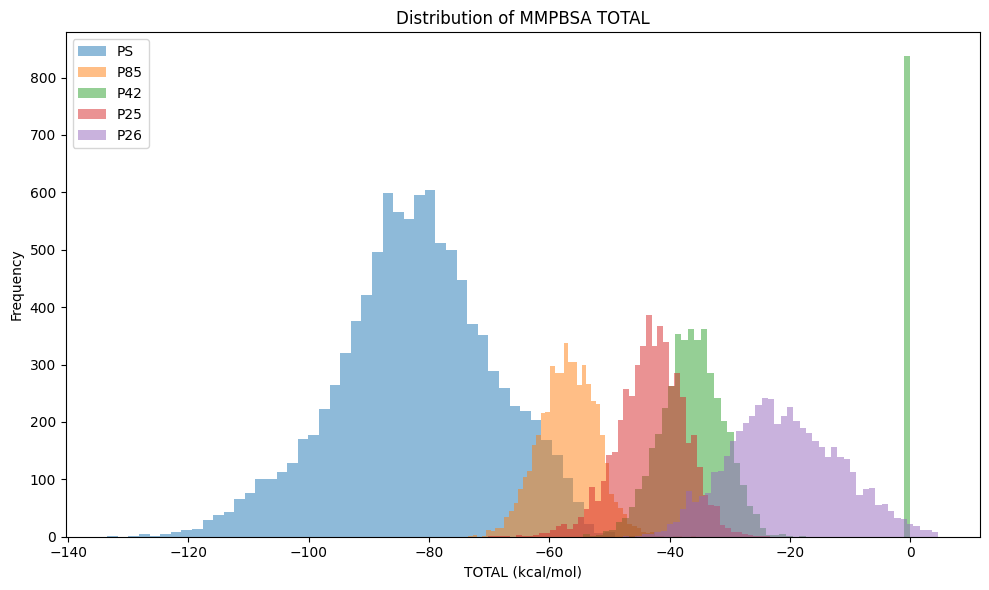

In [7]:
plt.figure(figsize=(10, 6))

plt.hist(df1['TOTAL'].dropna(), bins=50, alpha=0.5, label='PS')
plt.hist(df2['TOTAL'].dropna(), bins=50, alpha=0.5, label='P85')
plt.hist(df3['TOTAL'].dropna(), bins=50, alpha=0.5, label='P42')
plt.hist(df4['TOTAL'].dropna(), bins=50, alpha=0.5, label='P25')
plt.hist(df5['TOTAL'].dropna(), bins=50, alpha=0.5, label='P26')
plt.xlabel('TOTAL (kcal/mol)')
plt.ylabel('Frequency')
plt.title('Distribution of MMPBSA TOTAL')
plt.legend()
plt.tight_layout()
# plt.savefig('/media/leandro/My Passport/GUSB/dockings/dockings/project_gromacs/Distribution of MMPBSA TOTAL - Gluestradiol')
plt.show()

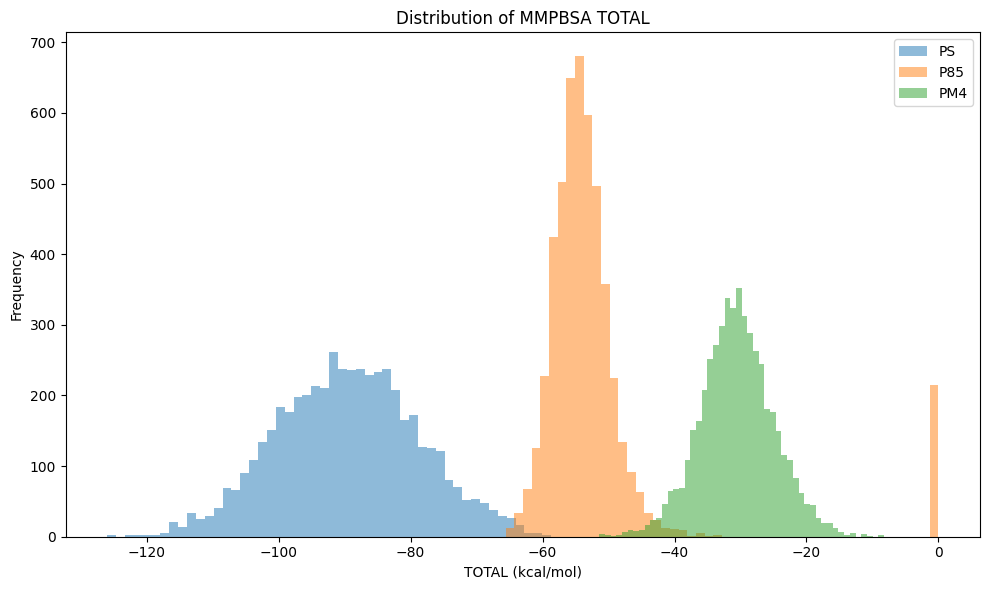

In [10]:
plt.figure(figsize=(10, 6))

plt.hist(df1['TOTAL'].dropna(), bins=50, alpha=0.5, label='PS')
plt.hist(df2['TOTAL'].dropna(), bins=50, alpha=0.5, label='P85')
plt.hist(df3['TOTAL'].dropna(), bins=50, alpha=0.5, label='PM4')

plt.xlabel('TOTAL (kcal/mol)')
plt.ylabel('Frequency')
plt.title('Distribution of MMPBSA TOTAL')
plt.legend()
plt.tight_layout()

plt.show()

In [89]:
import scipy.stats as ss

ss.ttest_ind(df1['TOTAL'], df2['TOTAL'])

TtestResult(statistic=19.743134169866952, pvalue=5.423589328057821e-86, df=21247.0)